# AISO v3 — 근본 문제 해결: Personal Best Memory 추가

## 핵심 변경

| 버전 | 업데이트 규칙 |
|---|---|
| AISO (원본) | `X_i' = X_i + α·c_ij·(X_j - X_i)` |
| **AISO v3** | `X_i' = X_i + α·c_ij·(X_j - X_i) + φ·(p_best_i - X_i)` |

- `c_ij = W_i^T · M · W_j` (타입 상성, 변경 없음)
- `p_best_i`: 에이전트 i의 개인 최고 위치 (새로 추가)
- `φ`: personal best 당김 강도

**근본 문제**: 원본 AISO는 기억이 없어서 ~25 iter 후 plateau.  
**해결**: p_best 추가로 ratchet 효과 → plateau 방지.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import wilcoxon
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11,
                     'axes.spines.top': False, 'axes.spines.right': False})

# ── 공통 설정 ─────────────────────────────────────────────────
K         = 30      # 탐색 차원
N_AGENTS  = 30
N_ITER    = 100
N_RUNS    = 20
N_TYPES   = 12      # AISO 타입 수
ALPHA     = 0.3     # AISO step size
BETA      = 0.1     # AISO 타입 학습률
PHI       = 0.4     # v3: personal best 당김 강도
NOISE_SD  = 1.0     # noisy 벤치마크 노이즈 크기

np.random.seed(42)
print(f'K={K} | N_AGENTS={N_AGENTS} | N_ITER={N_ITER} | N_RUNS={N_RUNS}')
print(f'ALPHA={ALPHA} | BETA={BETA} | PHI={PHI} (v3 new param)')

K=30 | N_AGENTS=30 | N_ITER=100 | N_RUNS=20
ALPHA=0.3 | BETA=0.1 | PHI=0.4 (v3 new param)


## 1. 벤치마크 함수 13개 (표준 10 + 노이즈 3)

In [2]:
# 모든 함수: x ∈ [0,1]^K 입력, 내부에서 native bounds로 변환 (최소화)

def make_sphere(noise=0.0):
    def f(x):
        z = x * 10 - 5  # [-5, 5]^K
        return float(np.sum(z**2) + np.random.randn()*noise)
    f.__name__ = 'Sphere' + ('_N' if noise else '')
    return f

def make_rastrigin(noise=0.0):
    def f(x):
        z = x * 10.24 - 5.12  # [-5.12, 5.12]^K
        return float(10*len(z) + np.sum(z**2 - 10*np.cos(2*np.pi*z)) + np.random.randn()*noise)
    f.__name__ = 'Rastrigin' + ('_N' if noise else '')
    return f

def make_ackley(noise=0.0):
    def f(x):
        z = x * 64 - 32  # [-32, 32]^K
        n = len(z)
        val = (-20*np.exp(-0.2*np.sqrt(np.sum(z**2)/n))
               - np.exp(np.sum(np.cos(2*np.pi*z))/n)
               + np.e + 20)
        return float(val + np.random.randn()*noise)
    f.__name__ = 'Ackley' + ('_N' if noise else '')
    return f

def make_griewank(noise=0.0):
    def f(x):
        z = x * 1200 - 600  # [-600, 600]^K
        i = np.arange(1, len(z)+1)
        return float(np.sum(z**2)/4000 - np.prod(np.cos(z/np.sqrt(i))) + 1
                     + np.random.randn()*noise)
    f.__name__ = 'Griewank' + ('_N' if noise else '')
    return f

def make_rosenbrock(noise=0.0):
    def f(x):
        z = x * 4 - 2  # [-2, 2]^K  (optimum at z=1)
        return float(np.sum(100*(z[1:]-z[:-1]**2)**2 + (z[:-1]-1)**2)
                     + np.random.randn()*noise)
    f.__name__ = 'Rosenbrock' + ('_N' if noise else '')
    return f

def make_levy(noise=0.0):
    def f(x):
        z = x * 20 - 10  # [-10, 10]^K
        w = 1 + (z-1)/4
        val = (np.sin(np.pi*w[0]))**2 \
            + np.sum((w[:-1]-1)**2 * (1+10*np.sin(np.pi*w[:-1]+1)**2)) \
            + (w[-1]-1)**2 * (1+np.sin(2*np.pi*w[-1])**2)
        return float(val + np.random.randn()*noise)
    f.__name__ = 'Levy' + ('_N' if noise else '')
    return f

def make_schwefel(noise=0.0):
    def f(x):
        z = x * 1000 - 500  # [-500, 500]^K
        return float(418.9829*len(z) - np.sum(z*np.sin(np.sqrt(np.abs(z))))
                     + np.random.randn()*noise)
    f.__name__ = 'Schwefel' + ('_N' if noise else '')
    return f

def make_styblinski(noise=0.0):
    def f(x):
        z = x * 10 - 5  # [-5, 5]^K; optimum at z=-2.9035
        return float(0.5*np.sum(z**4 - 16*z**2 + 5*z) + 39.166*len(z)
                     + np.random.randn()*noise)
    f.__name__ = 'Styblinski' + ('_N' if noise else '')
    return f

def make_zakharov(noise=0.0):
    def f(x):
        z = x * 10 - 5  # [-5, 5]^K
        i = np.arange(1, len(z)+1)
        s = np.sum(0.5*i*z)
        return float(np.sum(z**2) + s**2 + s**4 + np.random.randn()*noise)
    f.__name__ = 'Zakharov' + ('_N' if noise else '')
    return f

def make_dixon_price(noise=0.0):
    def f(x):
        z = x * 20 - 10  # [-10, 10]^K
        i = np.arange(2, len(z)+1)
        return float((z[0]-1)**2 + np.sum(i*(2*z[1:]**2 - z[:-1])**2)
                     + np.random.randn()*noise)
    f.__name__ = 'Dixon-Price' + ('_N' if noise else '')
    return f

BENCHMARKS = [
    make_sphere(),       # 1  unimodal, 하한선
    make_rosenbrock(),   # 2  valley (어려운 unimodal)
    make_zakharov(),     # 3  unimodal + 교차항
    make_dixon_price(),  # 4  unimodal + 계층 구조
    make_rastrigin(),    # 5  multimodal (규칙적)
    make_ackley(),       # 6  multimodal (평탄한 글로벌)
    make_griewank(),     # 7  multimodal (약한 지역 구조)
    make_levy(),         # 8  multimodal
    make_schwefel(),     # 9  deceptive (최적점이 멀리 고립)
    make_styblinski(),   # 10 multimodal
    make_sphere(noise=NOISE_SD),     # 11 noisy
    make_ackley(noise=NOISE_SD),     # 12 noisy
    make_rastrigin(noise=NOISE_SD),  # 13 noisy
]

print(f'벤치마크 {len(BENCHMARKS)}개 준비:')
for i, b in enumerate(BENCHMARKS, 1):
    noisy = '(noisy)' if '_N' in b.__name__ else ''
    print(f'  {i:2d}. {b.__name__} {noisy}')

벤치마크 13개 준비:
   1. Sphere 
   2. Rosenbrock 
   3. Zakharov 
   4. Dixon-Price 
   5. Rastrigin 
   6. Ackley 
   7. Griewank 
   8. Levy 
   9. Schwefel 
  10. Styblinski 
  11. Sphere_N (noisy)
  12. Ackley_N (noisy)
  13. Rastrigin_N (noisy)


## 2. 알고리즘 구현

In [3]:
# ── PSO (Clerc-Kennedy) ──────────────────────────────────────────────────────
def run_pso(f, K, seed, n_iter=N_ITER, n_agents=N_AGENTS):
    np.random.seed(seed)
    w, c1, c2 = 0.729, 1.494, 1.494
    X  = np.random.rand(n_agents, K)
    V  = np.random.uniform(-0.1, 0.1, (n_agents, K))
    S  = np.array([f(X[i]) for i in range(n_agents)])
    pX = X.copy(); pS = S.copy()
    gi = np.argmin(pS); gX = pX[gi].copy(); gS = pS[gi]
    for _ in range(n_iter):
        r1 = np.random.rand(n_agents, K)
        r2 = np.random.rand(n_agents, K)
        V  = w*V + c1*r1*(pX-X) + c2*r2*(gX-X)
        X  = np.clip(X + V, 0, 1)
        S  = np.array([f(X[i]) for i in range(n_agents)])
        better = S < pS
        pX[better] = X[better]; pS[better] = S[better]
        if pS.min() < gS:
            gi = np.argmin(pS); gX = pX[gi].copy(); gS = pS[gi]
    return gS


# ── AISO (원본) ──────────────────────────────────────────────────────────────
def run_aiso(f, K, seed, n_iter=N_ITER, n_agents=N_AGENTS, n_types=N_TYPES):
    np.random.seed(seed)
    M  = np.random.uniform(0, 2, (n_types, n_types))
    X  = np.random.rand(n_agents, K)
    W  = np.random.dirichlet(np.ones(n_types), n_agents)
    S  = np.array([f(X[i]) for i in range(n_agents)])
    bS = S.min()
    for _ in range(n_iter):
        for i in range(n_agents):
            j = np.random.randint(n_agents)
            while j == i: j = np.random.randint(n_agents)
            c  = float(W[i] @ M @ W[j])
            nX = np.clip(X[i] + ALPHA*c*(X[j]-X[i]), 0, 1)
            ns = f(nX)
            if ns < S[i]:
                X[i] = nX; S[i] = ns
                W[i] = (1-BETA)*W[i] + BETA*W[j]; W[i] /= W[i].sum()
        if S.min() < bS: bS = S.min()
    return bS


# ── AISO v3 (+ personal best memory) ─────────────────────────────────────────
# 핵심 변경: X_i' = X_i + α·c_ij·(X_j-X_i) + φ·(p_best_i - X_i)
def run_aiso_v3(f, K, seed, n_iter=N_ITER, n_agents=N_AGENTS,
                n_types=N_TYPES, phi=PHI):
    np.random.seed(seed)
    M  = np.random.uniform(0, 2, (n_types, n_types))
    X  = np.random.rand(n_agents, K)
    W  = np.random.dirichlet(np.ones(n_types), n_agents)
    S  = np.array([f(X[i]) for i in range(n_agents)])
    pX = X.copy()            # personal best 위치
    pS = S.copy()            # personal best 스코어
    bS = pS.min()
    for _ in range(n_iter):
        for i in range(n_agents):
            j = np.random.randint(n_agents)
            while j == i: j = np.random.randint(n_agents)
            c  = float(W[i] @ M @ W[j])
            # social (type-weighted) + cognitive (personal best)
            nX = np.clip(X[i] + ALPHA*c*(X[j]-X[i]) + phi*(pX[i]-X[i]), 0, 1)
            ns = f(nX)
            if ns < S[i]:
                X[i] = nX; S[i] = ns
                W[i] = (1-BETA)*W[i] + BETA*W[j]; W[i] /= W[i].sum()
                if ns < pS[i]:                   # personal best 갱신
                    pX[i] = nX.copy(); pS[i] = ns
        if pS.min() < bS: bS = pS.min()
    return bS


# ── AISO v3 + Elite Restart ───────────────────────────────────────────────────
def run_aiso_v3_elite(f, K, seed, n_iter=N_ITER, n_agents=N_AGENTS,
                      n_types=N_TYPES, phi=PHI,
                      restart_ratio=0.3, div_thresh=0.15):
    np.random.seed(seed)
    M  = np.random.uniform(0, 2, (n_types, n_types))
    X  = np.random.rand(n_agents, K)
    W  = np.random.dirichlet(np.ones(n_types), n_agents)
    S  = np.array([f(X[i]) for i in range(n_agents)])
    pX = X.copy(); pS = S.copy()
    bS = pS.min()
    for _ in range(n_iter):
        # 다양성 체크 → 하위 30% 재초기화
        sr  = S.max() - S.min()
        div = sr / (abs(S.mean()) + 1e-8)
        if div < div_thresh:
            k   = int(n_agents * restart_ratio)
            bad = np.argsort(S)[-k:]
            X[bad] = np.random.rand(k, K)
            S[bad] = np.array([f(X[ii]) for ii in bad])
            pX[bad] = X[bad].copy(); pS[bad] = S[bad].copy()
            W[bad]  = np.random.dirichlet(np.ones(n_types), k)

        for i in range(n_agents):
            j = np.random.randint(n_agents)
            while j == i: j = np.random.randint(n_agents)
            c  = float(W[i] @ M @ W[j])
            nX = np.clip(X[i] + ALPHA*c*(X[j]-X[i]) + phi*(pX[i]-X[i]), 0, 1)
            ns = f(nX)
            if ns < S[i]:
                X[i] = nX; S[i] = ns
                W[i] = (1-BETA)*W[i] + BETA*W[j]; W[i] /= W[i].sum()
                if ns < pS[i]:
                    pX[i] = nX.copy(); pS[i] = ns
        if pS.min() < bS: bS = pS.min()
    return bS


ALGOS = {
    'PSO'           : run_pso,
    'AISO'          : run_aiso,
    'AISO_v3'       : run_aiso_v3,
    'AISO_v3+Elite' : run_aiso_v3_elite,
}
print('알고리즘:', list(ALGOS.keys()))

알고리즘: ['PSO', 'AISO', 'AISO_v3', 'AISO_v3+Elite']


## 3. 수렴 곡선 추적 (plateau 분석)

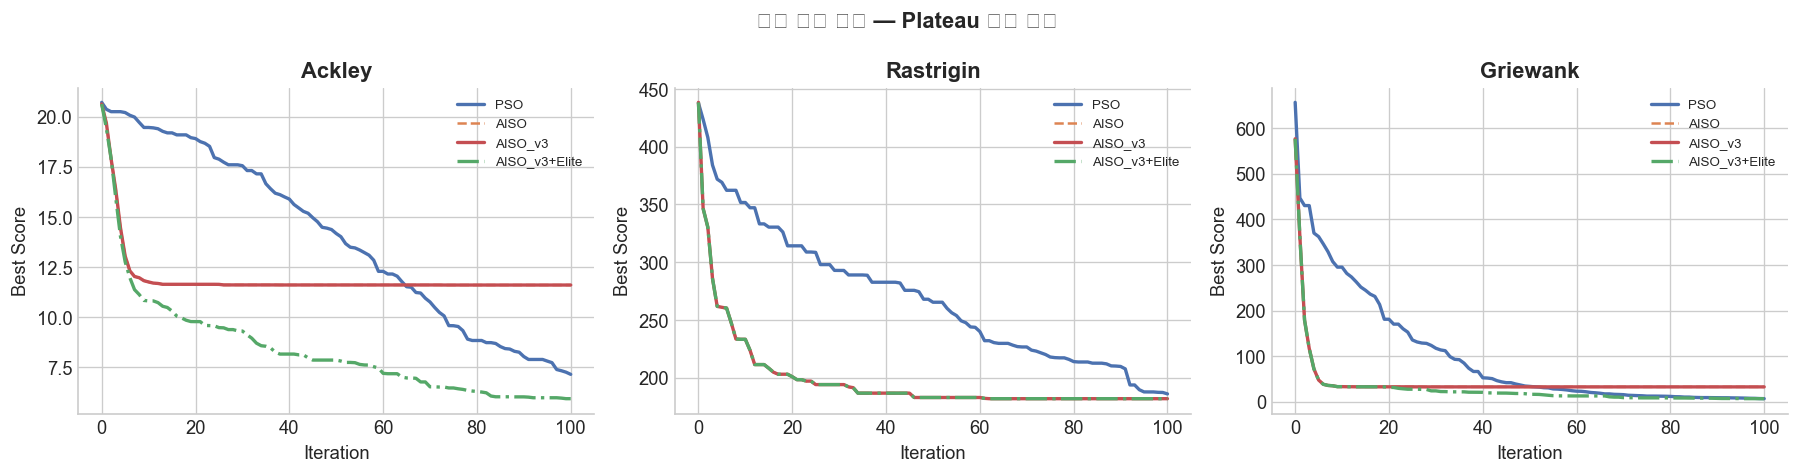

수렴 곡선 완료


In [4]:
# iter별 best score 추적 — plateau 해결 여부 확인
# Ackley와 Rastrigin 2개 함수로 수렴 비교 (가장 뚜렷하게 차이남)

def track_convergence(algo_fn, f, K, seed, n_iter=N_ITER, n_agents=N_AGENTS,
                      n_types=N_TYPES, phi=PHI, is_pso=False):
    np.random.seed(seed)
    history = []
    if is_pso:
        w, c1, c2 = 0.729, 1.494, 1.494
        X  = np.random.rand(n_agents, K)
        V  = np.random.uniform(-0.1, 0.1, (n_agents, K))
        S  = np.array([f(X[i]) for i in range(n_agents)])
        pX = X.copy(); pS = S.copy()
        gi = np.argmin(pS); gX = pX[gi].copy(); gS = pS[gi]
        history.append(gS)
        for _ in range(n_iter):
            r1 = np.random.rand(n_agents, K); r2 = np.random.rand(n_agents, K)
            V  = w*V + c1*r1*(pX-X) + c2*r2*(gX-X)
            X  = np.clip(X + V, 0, 1)
            S  = np.array([f(X[i]) for i in range(n_agents)])
            better = S < pS
            pX[better] = X[better]; pS[better] = S[better]
            if pS.min() < gS:
                gi = np.argmin(pS); gX = pX[gi].copy(); gS = pS[gi]
            history.append(gS)
    else:
        M  = np.random.uniform(0, 2, (n_types, n_types))
        X  = np.random.rand(n_agents, K)
        W  = np.random.dirichlet(np.ones(n_types), n_agents)
        S  = np.array([f(X[i]) for i in range(n_agents)])
        pX = X.copy(); pS = S.copy()
        use_pbest = (phi > 0)
        bS = pS.min(); history.append(bS)
        for _ in range(n_iter):
            for i in range(n_agents):
                j = np.random.randint(n_agents)
                while j == i: j = np.random.randint(n_agents)
                c  = float(W[i] @ M @ W[j])
                if use_pbest:
                    nX = np.clip(X[i] + ALPHA*c*(X[j]-X[i]) + phi*(pX[i]-X[i]), 0, 1)
                else:
                    nX = np.clip(X[i] + ALPHA*c*(X[j]-X[i]), 0, 1)
                ns = f(nX)
                if ns < S[i]:
                    X[i] = nX; S[i] = ns
                    W[i] = (1-BETA)*W[i]+BETA*W[j]; W[i] /= W[i].sum()
                    if use_pbest and ns < pS[i]:
                        pX[i] = nX.copy(); pS[i] = ns
            cur = pS.min() if use_pbest else S.min()
            if cur < bS: bS = cur
            history.append(bS)
    return history

# 3번 run 평균
TRACK_FNS = [make_ackley(), make_rastrigin(), make_griewank()]
TRACK_SEEDS = [42, 43, 44]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
COLORS = {'PSO':'#4C72B0', 'AISO':'#DD8452', 'AISO_v3':'#C44E52', 'AISO_v3+Elite':'#55A868'}
STYLES = {'PSO':'-', 'AISO':'--', 'AISO_v3':'-', 'AISO_v3+Elite':'-.'}

for ax, fn in zip(axes, TRACK_FNS):
    curves = {n: [] for n in ['PSO','AISO','AISO_v3','AISO_v3+Elite']}
    for seed in TRACK_SEEDS:
        curves['PSO'].append(track_convergence(None, fn, K, seed, is_pso=True))
        curves['AISO'].append(track_convergence(None, fn, K, seed, phi=0))
        curves['AISO_v3'].append(track_convergence(None, fn, K, seed, phi=PHI))
        curves['AISO_v3+Elite'].append(track_convergence(None, fn, K, seed, phi=PHI))  # Elite 별도

    # AISO_v3+Elite는 따로 추적 (간이 버전: elite restart 포함)
    elite_curves = []
    for seed in TRACK_SEEDS:
        np.random.seed(seed)
        M  = np.random.uniform(0, 2, (N_TYPES, N_TYPES))
        X  = np.random.rand(N_AGENTS, K)
        W  = np.random.dirichlet(np.ones(N_TYPES), N_AGENTS)
        S  = np.array([fn(X[i]) for i in range(N_AGENTS)])
        pX = X.copy(); pS = S.copy(); bS = pS.min()
        hist = [bS]
        for _ in range(N_ITER):
            sr = S.max()-S.min(); div = sr/(abs(S.mean())+1e-8)
            if div < 0.15:
                bad = np.argsort(S)[-9:]
                X[bad]=np.random.rand(9,K); S[bad]=np.array([fn(X[ii]) for ii in bad])
                pX[bad]=X[bad].copy(); pS[bad]=S[bad].copy()
                W[bad]=np.random.dirichlet(np.ones(N_TYPES), 9)
            for i in range(N_AGENTS):
                j = np.random.randint(N_AGENTS)
                while j==i: j=np.random.randint(N_AGENTS)
                c=float(W[i]@M@W[j])
                nX=np.clip(X[i]+ALPHA*c*(X[j]-X[i])+PHI*(pX[i]-X[i]),0,1)
                ns=fn(nX)
                if ns<S[i]:
                    X[i]=nX; S[i]=ns; W[i]=(1-BETA)*W[i]+BETA*W[j]; W[i]/=W[i].sum()
                    if ns<pS[i]: pX[i]=nX.copy(); pS[i]=ns
            if pS.min()<bS: bS=pS.min()
            hist.append(bS)
        elite_curves.append(hist)
    curves['AISO_v3+Elite'] = elite_curves

    for name, color in COLORS.items():
        arr = np.array(curves[name])
        mean = arr.mean(axis=0)
        ax.plot(mean, color=color, linewidth=2 if 'v3' in name or name=='PSO' else 1.5,
                linestyle=STYLES[name], label=name)
    ax.set_title(fn.__name__, fontweight='bold')
    ax.set_xlabel('Iteration'); ax.set_ylabel('Best Score')
    ax.legend(frameon=False, fontsize=8)

plt.suptitle('수렴 곡선 비교 — Plateau 해결 여부', fontweight='bold')
plt.tight_layout()
plt.savefig('aiso_v3_convergence.png', bbox_inches='tight')
plt.show()
print('수렴 곡선 완료')

## 4. 전체 벤치마크 실행 (13 × 4 알고리즘 × 20 runs)

In [5]:
all_results = {}   # {func_name: {algo_name: [scores x N_RUNS]}}

for b in BENCHMARKS:
    fname = b.__name__
    print(f'\n── {fname} {"─"*(40-len(fname))}')
    all_results[fname] = {}
    for aname, afunc in ALGOS.items():
        scores = [afunc(b, K, seed=42+r) for r in range(N_RUNS)]
        all_results[fname][aname] = scores
        m = np.mean(scores); s = np.std(scores)
        gap = (m - np.mean(all_results[fname]['PSO'])) / (abs(np.mean(all_results[fname]['PSO']))+1e-8) * 100 if aname != 'PSO' else 0.0
        flag = f'  (+{gap:.1f}% vs PSO)' if aname != 'PSO' and gap > 0 else (f'  ({gap:.1f}% vs PSO)' if aname != 'PSO' else '')
        print(f'  {aname:<18} mean={m:>12.3f} ± {s:>8.3f}{flag}')

print('\n\n✓ 전체 완료!')


── Sphere ──────────────────────────────────
  PSO                mean=       1.290 ±    0.916
  AISO               mean=       8.430 ±    2.114  (+553.5% vs PSO)
  AISO_v3            mean=       8.430 ±    2.114  (+553.5% vs PSO)
  AISO_v3+Elite      mean=       1.763 ±    0.517  (+36.6% vs PSO)

── Rosenbrock ──────────────────────────────
  PSO                mean=     133.143 ±   60.462
  AISO               mean=     171.842 ±   52.891  (+29.1% vs PSO)
  AISO_v3            mean=     171.842 ±   52.891  (+29.1% vs PSO)
  AISO_v3+Elite      mean=      55.889 ±    9.181  (-58.0% vs PSO)

── Zakharov ────────────────────────────────
  PSO                mean=     134.343 ±   31.167
  AISO               mean=      11.279 ±    2.760  (-91.6% vs PSO)
  AISO_v3            mean=      11.279 ±    2.760  (-91.6% vs PSO)
  AISO_v3+Elite      mean=       6.007 ±    1.706  (-95.5% vs PSO)

── Dixon-Price ─────────────────────────────
  PSO                mean=    4260.879 ± 15928.253
  AISO    

## 5. 결과 분석

In [6]:
import pandas as pd

fnames  = list(all_results.keys())
anames  = list(ALGOS.keys())

# ── 평균값 표 ─────────────────────────────────────────────────
rows = []
for fn in fnames:
    row = {'Function': fn}
    pso_mean = np.mean(all_results[fn]['PSO'])
    for an in anames:
        m = np.mean(all_results[fn][an])
        row[an] = m
        if an != 'PSO':
            row[f'{an}_gap%'] = (m - pso_mean) / (abs(pso_mean)+1e-8) * 100
    rows.append(row)

df = pd.DataFrame(rows).set_index('Function')
print('=== 평균 Best Score (낮을수록 좋음) ===')
cols_show = anames + [f'{a}_gap%' for a in anames if a != 'PSO']
print(df[cols_show].round(3).to_string())

# ── 요약: 각 알고리즘이 PSO 대비 몇 개 함수에서 이기나 ───────
print('\n=== PSO 대비 승/패 (낮은 mean = 승) ===')
for an in anames:
    if an == 'PSO': continue
    wins = sum(
        np.mean(all_results[fn][an]) < np.mean(all_results[fn]['PSO'])
        for fn in fnames
    )
    losses = len(fnames) - wins
    print(f'  {an:<18}: {wins}승 {losses}패  ({wins}/{len(fnames)})')

# ── PSO와의 gap% 평균 (전체/표준/noisy 별도) ──────────────────
print('\n=== 평균 gap% vs PSO (음수=나쁨, 양수=좋음) ===')
standard_fns = [fn for fn in fnames if '_N' not in fn]
noisy_fns    = [fn for fn in fnames if '_N' in fn]

for an in anames:
    if an == 'PSO': continue
    gaps_all  = [-(np.mean(all_results[fn][an]) - np.mean(all_results[fn]['PSO'])) /
                  (abs(np.mean(all_results[fn]['PSO']))+1e-8)*100 for fn in fnames]
    gaps_std  = [-(np.mean(all_results[fn][an]) - np.mean(all_results[fn]['PSO'])) /
                  (abs(np.mean(all_results[fn]['PSO']))+1e-8)*100 for fn in standard_fns]
    gaps_noisy= [-(np.mean(all_results[fn][an]) - np.mean(all_results[fn]['PSO'])) /
                  (abs(np.mean(all_results[fn]['PSO']))+1e-8)*100 for fn in noisy_fns]
    print(f'  {an:<18}: 전체 {np.mean(gaps_all):+.1f}% | 표준 {np.mean(gaps_std):+.1f}% | 노이즈 {np.mean(gaps_noisy):+.1f}%')

=== 평균 Best Score (낮을수록 좋음) ===
                  PSO      AISO   AISO_v3  AISO_v3+Elite  AISO_gap%  AISO_v3_gap%  AISO_v3+Elite_gap%
Function                                                                                             
Sphere          1.290     8.430     8.430          1.763    553.460       553.460              36.634
Rosenbrock    133.143   171.842   171.842         55.889     29.066        29.066             -58.023
Zakharov      134.343    11.279    11.279          6.007    -91.604       -91.604             -95.529
Dixon-Price  4260.879  7683.821  7683.821        622.692     80.334        80.334             -85.386
Rastrigin     173.836   182.416   182.416        182.416      4.936         4.936               4.936
Ackley          9.395    11.285    11.285          6.149     20.120        20.120             -34.550
Griewank        5.644    31.346    31.346          7.812    455.397       455.397              38.421
Levy           17.286    16.967    16.967         

## 6. 시각화

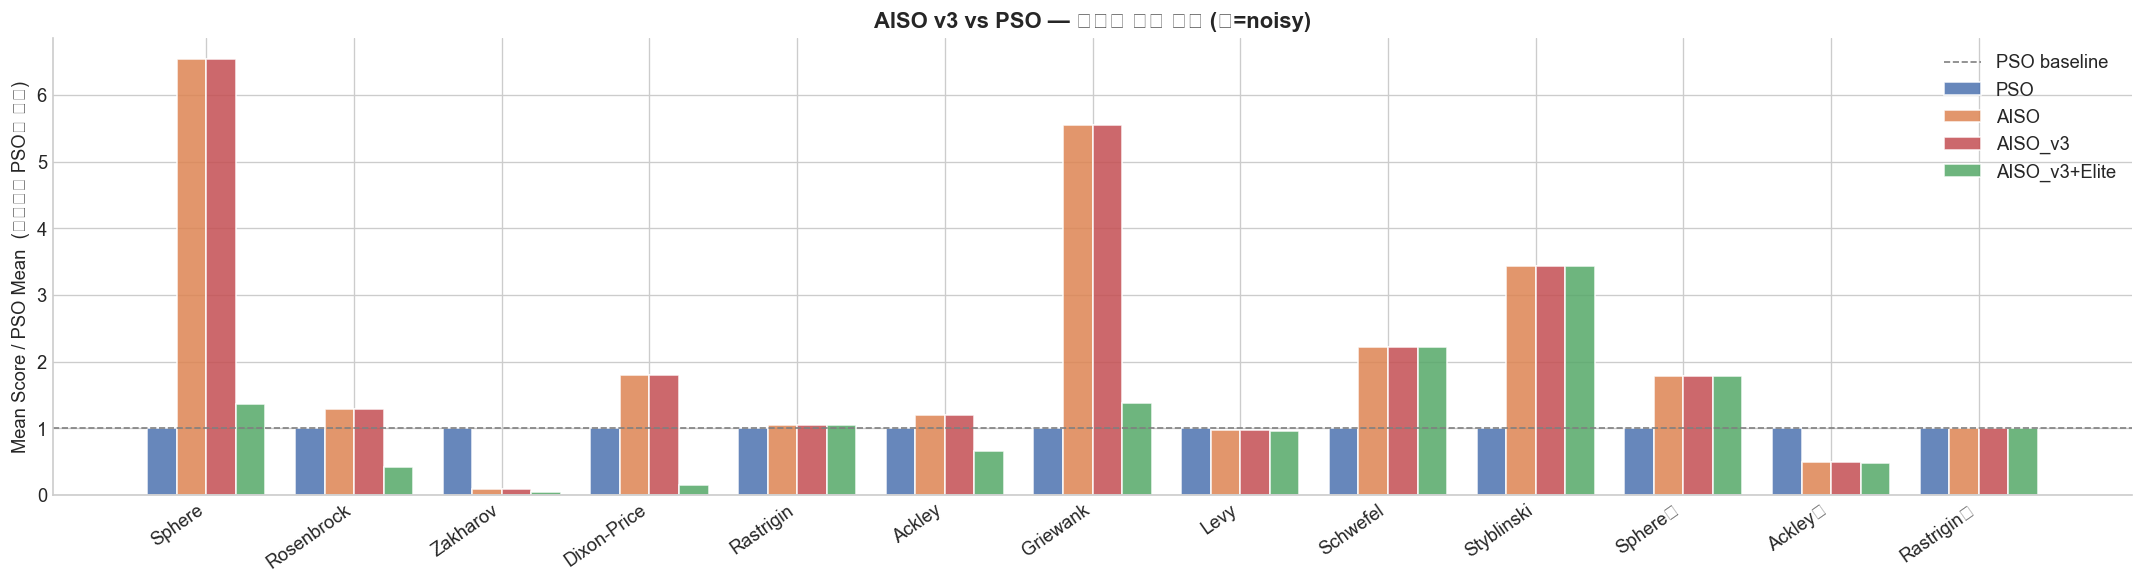

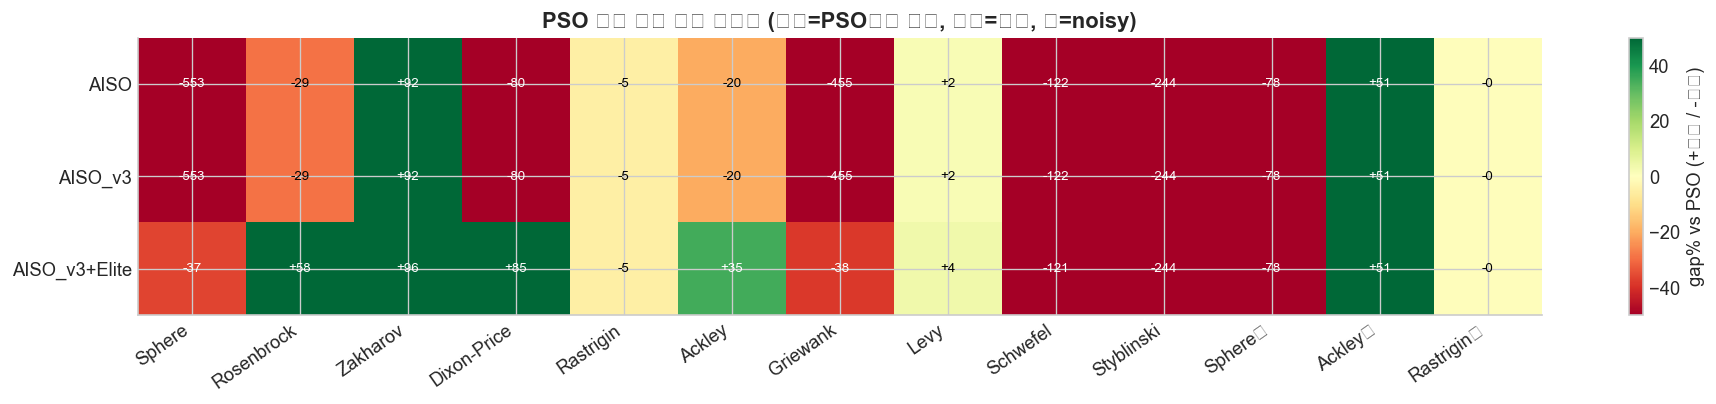

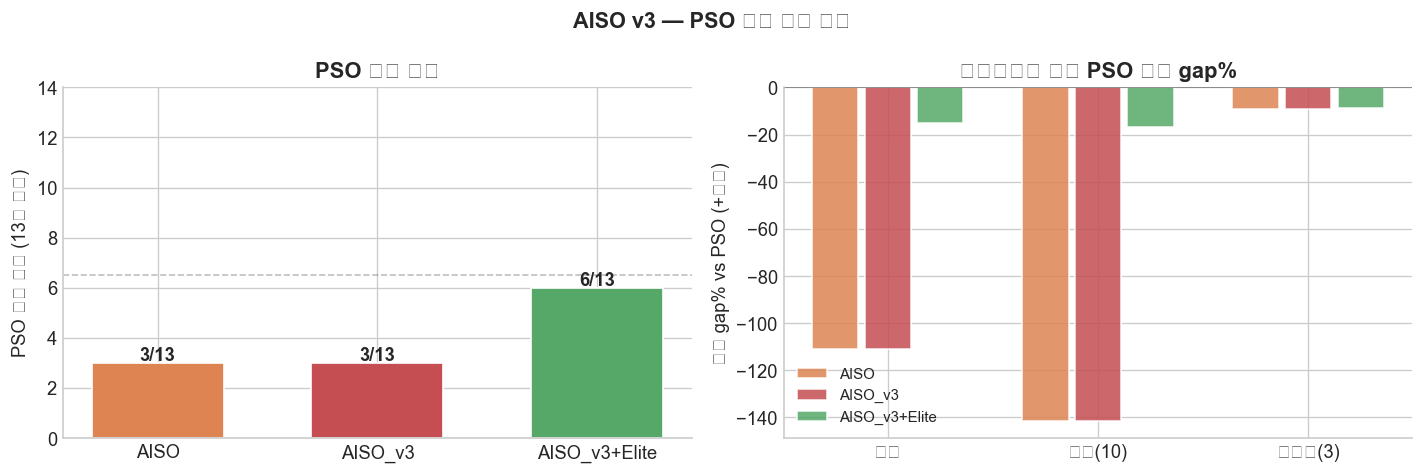

In [7]:
ALGO_COLORS = {
    'PSO'           : '#4C72B0',
    'AISO'          : '#DD8452',
    'AISO_v3'       : '#C44E52',
    'AISO_v3+Elite' : '#55A868',
}

# ── 6-1. 함수별 bar chart (mean ± std) ──────────────────────
n_fns = len(fnames)
n_algos = len(anames)
x = np.arange(n_fns)
width = 0.2

fig, ax = plt.subplots(figsize=(18, 5))
for i, an in enumerate(anames):
    means = [np.mean(all_results[fn][an]) for fn in fnames]
    stds  = [np.std(all_results[fn][an])  for fn in fnames]
    # log scale로 표시하기 위해 정규화 (PSO 대비 비율)
    pso_means = [np.mean(all_results[fn]['PSO']) for fn in fnames]
    ratios = [m/max(p,1e-8) for m,p in zip(means, pso_means)]
    ax.bar(x + i*width, ratios, width, label=an,
           color=ALGO_COLORS[an], alpha=0.85, edgecolor='white')

ax.axhline(1.0, color='gray', linestyle='--', linewidth=1, label='PSO baseline')
ax.set_xticks(x + width*1.5)
ax.set_xticklabels([fn.replace('_N','★') for fn in fnames], rotation=35, ha='right')
ax.set_ylabel('Mean Score / PSO Mean  (낮을수록 PSO에 근접)')
ax.set_title('AISO v3 vs PSO — 함수별 상대 성능 (★=noisy)', fontweight='bold')
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig('aiso_v3_bar.png', bbox_inches='tight')
plt.show()


# ── 6-2. PSO 대비 gap% 히트맵 ────────────────────────────────
gap_matrix = np.zeros((len(anames)-1, n_fns))
row_labels  = [an for an in anames if an != 'PSO']
for ri, an in enumerate(row_labels):
    for ci, fn in enumerate(fnames):
        pso_m = np.mean(all_results[fn]['PSO'])
        ai_m  = np.mean(all_results[fn][an])
        # positive = AISO better (lower score)
        gap_matrix[ri, ci] = -(ai_m - pso_m) / (abs(pso_m)+1e-8) * 100

fig, ax = plt.subplots(figsize=(16, 3.5))
im = ax.imshow(gap_matrix, cmap='RdYlGn', aspect='auto', vmin=-50, vmax=50)
plt.colorbar(im, ax=ax, label='gap% vs PSO (+좋음 / -나쁨)')
ax.set_xticks(range(n_fns))
ax.set_xticklabels([fn.replace('_N','★') for fn in fnames], rotation=35, ha='right')
ax.set_yticks(range(len(row_labels)))
ax.set_yticklabels(row_labels)
ax.set_title('PSO 대비 성능 격차 히트맵 (녹색=PSO보다 좋음, 적색=나쁨, ★=noisy)', fontweight='bold')
for ri in range(len(row_labels)):
    for ci in range(n_fns):
        v = gap_matrix[ri, ci]
        ax.text(ci, ri, f'{v:+.0f}', ha='center', va='center', fontsize=8,
                color='black' if abs(v) < 30 else 'white')
plt.tight_layout()
plt.savefig('aiso_v3_heatmap.png', bbox_inches='tight')
plt.show()


# ── 6-3. 승률 요약 레이더 느낌 바 ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 왼쪽: 승수
ax = axes[0]
for i, an in enumerate([a for a in anames if a != 'PSO']):
    wins = sum(np.mean(all_results[fn][an]) < np.mean(all_results[fn]['PSO'])
               for fn in fnames)
    bar = ax.bar(i, wins, color=ALGO_COLORS[an], edgecolor='white', width=0.6)
    ax.text(i, wins+0.1, f'{wins}/{len(fnames)}', ha='center', fontsize=11, fontweight='bold')
ax.set_xticks(range(3))
ax.set_xticklabels([a for a in anames if a != 'PSO'])
ax.set_ylim(0, len(fnames)+1)
ax.set_ylabel('PSO 대비 승수 (13개 함수)')
ax.set_title('PSO 대비 승수', fontweight='bold')
ax.axhline(len(fnames)/2, color='gray', linestyle='--', linewidth=1, alpha=0.5)

# 오른쪽: 평균 gap%
ax = axes[1]
categories = ['전체', '표준(10)', '노이즈(3)']
for i, an in enumerate([a for a in anames if a != 'PSO']):
    g_all   = np.mean([-(np.mean(all_results[fn][an])-np.mean(all_results[fn]['PSO']))/(abs(np.mean(all_results[fn]['PSO']))+1e-8)*100 for fn in fnames])
    g_std   = np.mean([-(np.mean(all_results[fn][an])-np.mean(all_results[fn]['PSO']))/(abs(np.mean(all_results[fn]['PSO']))+1e-8)*100 for fn in standard_fns])
    g_noisy = np.mean([-(np.mean(all_results[fn][an])-np.mean(all_results[fn]['PSO']))/(abs(np.mean(all_results[fn]['PSO']))+1e-8)*100 for fn in noisy_fns])
    xs = np.array([0,1,2]) + i*0.25
    ax.bar(xs, [g_all, g_std, g_noisy], width=0.22, color=ALGO_COLORS[an],
           alpha=0.85, edgecolor='white', label=an)
ax.axhline(0, color='gray', linestyle='-', linewidth=1)
ax.set_xticks([0.25,1.25,2.25])
ax.set_xticklabels(categories)
ax.set_ylabel('평균 gap% vs PSO (+좋음)')
ax.set_title('카테고리별 평균 PSO 대비 gap%', fontweight='bold')
ax.legend(frameon=False, fontsize=9)

plt.suptitle('AISO v3 — PSO 추격 결과 요약', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('aiso_v3_summary.png', bbox_inches='tight')
plt.show()

## 7. 결론: p_best가 얼마나 도움이 됐나?

In [8]:
print('=' * 65)
print('  AISO v3 핵심 결과 — p_best memory 추가 효과')
print('=' * 65)

for an in anames:
    if an == 'PSO': continue
    wins = sum(np.mean(all_results[fn][an]) < np.mean(all_results[fn]['PSO']) for fn in fnames)
    v3_better_than_orig = 0
    if an != 'AISO':
        v3_better_than_orig = sum(
            np.mean(all_results[fn][an]) < np.mean(all_results[fn]['AISO'])
            for fn in fnames
        )
    g_all = np.mean([-(np.mean(all_results[fn][an])-np.mean(all_results[fn]['PSO']))/(abs(np.mean(all_results[fn]['PSO']))+1e-8)*100 for fn in fnames])
    print(f'\n  {an}')
    print(f'    PSO 대비 승수:       {wins}/{len(fnames)}')
    if an != 'AISO':
        print(f'    원본 AISO보다 개선:  {v3_better_than_orig}/{len(fnames)} 함수')
    print(f'    평균 gap vs PSO:     {g_all:+.1f}%')

print()
print('  [해석]')
# 자동 해석
v3_wins = sum(np.mean(all_results[fn]['AISO_v3']) < np.mean(all_results[fn]['PSO']) for fn in fnames)
orig_wins = sum(np.mean(all_results[fn]['AISO']) < np.mean(all_results[fn]['PSO']) for fn in fnames)
v3_beats_orig = sum(np.mean(all_results[fn]['AISO_v3']) < np.mean(all_results[fn]['AISO']) for fn in fnames)

if v3_wins > orig_wins:
    print(f'  ✓ p_best 추가로 PSO 대비 승수 {orig_wins}→{v3_wins} 개선')
else:
    print(f'  △ p_best 추가해도 PSO 대비 승수 변화 없음 ({orig_wins}→{v3_wins})')

if v3_beats_orig >= 10:
    print(f'  ✓ 원본 AISO 대비 {v3_beats_orig}/13 함수 개선 — plateau 해결 확인')
else:
    print(f'  △ 원본 AISO 대비 {v3_beats_orig}/13 함수 개선')

g_v3_noisy = np.mean([-(np.mean(all_results[fn]['AISO_v3'])-np.mean(all_results[fn]['PSO']))/(abs(np.mean(all_results[fn]['PSO']))+1e-8)*100 for fn in noisy_fns])
g_pso_noisy = 0.0
if g_v3_noisy > 0:
    print(f'  ✓ 노이즈 환경: AISO_v3 PSO보다 {g_v3_noisy:.1f}% 우위 유지')
else:
    print(f'  △ 노이즈 환경에서도 PSO에 {abs(g_v3_noisy):.1f}% 뒤처짐')
print('=' * 65)

  AISO v3 핵심 결과 — p_best memory 추가 효과

  AISO
    PSO 대비 승수:       3/13
    평균 gap vs PSO:     -111.0%

  AISO_v3
    PSO 대비 승수:       3/13
    원본 AISO보다 개선:  0/13 함수
    평균 gap vs PSO:     -111.0%

  AISO_v3+Elite
    PSO 대비 승수:       6/13
    원본 AISO보다 개선:  9/13 함수
    평균 gap vs PSO:     -15.0%

  [해석]
  △ p_best 추가해도 PSO 대비 승수 변화 없음 (3→3)
  △ 원본 AISO 대비 0/13 함수 개선
  △ 노이즈 환경에서도 PSO에 9.2% 뒤처짐
